# Template Eksperimen MSML
Ini adalah notebook untuk melakukan eksperimen EDA dan Preprocessing secara manual sesuai dengan Kriteria 1.

# 1. Perkenalan Dataset

Dataset yang digunakan dalam eksperimen ini adalah **Student Performance Dataset** yang diperoleh dari UCI Machine Learning Repository.

**Deskripsi Dataset**:
Dataset ini berisi data pencapaian akademik siswa pendidikan menengah dari dua sekolah di Portugal. Fitur-fitur (kolom) pada data ini mencakup nilai siswa (G1, G2, dan target akhir G3), data demografis (umur, jenis kelamin, alamat rumah), lingkungan sosial dan keluarga (pendidikan orang tua, ukuran keluarga, status kohabitasi), serta gaya hidup dan kebiasaan yang berkaitan dengan sekolah (waktu belajar tambahan, jumlah absen, waktu luang, konsumsi alkohol, dsb).

**Tujuan / Problem Statement**:
Tujuan dari pemodelan ini adalah memprediksi nilai akademik akhir siswa (kolom G3) berdasarkan fitur sosial, demografis, dan belajarnya. Dengan demikian, model Machine Learning ini dapat membantu pihak sekolah untuk mendeteksi dini siswa-siswa yang berisiko gagal atau mendapat nilai rendah, sehingga intervensi/bantuan belajar yang tepat bisa segera diberikan.

# 2. Import Library

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

# 3. Memuat Dataset

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.
Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.
Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset
train_df = pd.read_csv('student_raw/train.csv')
test_df = pd.read_csv('student_raw/test.csv')
train_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,M,16,U,GT3,T,3,3,services,other,...,4,2,3,1,2,3,2,12,13,12
1,GP,M,16,U,GT3,T,2,3,other,other,...,5,3,3,1,1,3,0,13,14,14
2,GP,F,16,U,GT3,T,1,3,at_home,services,...,4,3,5,1,1,3,0,8,7,0
3,GP,F,16,U,GT3,T,4,3,teacher,health,...,3,4,4,2,4,4,2,10,9,9
4,GP,M,16,R,GT3,T,2,1,other,other,...,3,3,2,1,3,3,0,8,9,8


# 4. Exploratory Data Analysis (EDA)

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.
Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316 entries, 0 to 315
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      316 non-null    object
 1   sex         316 non-null    object
 2   age         316 non-null    int64 
 3   address     316 non-null    object
 4   famsize     316 non-null    object
 5   Pstatus     316 non-null    object
 6   Medu        316 non-null    int64 
 7   Fedu        316 non-null    int64 
 8   Mjob        316 non-null    object
 9   Fjob        316 non-null    object
 10  reason      316 non-null    object
 11  guardian    316 non-null    object
 12  traveltime  316 non-null    int64 
 13  studytime   316 non-null    int64 
 14  failures    316 non-null    int64 
 15  schoolsup   316 non-null    object
 16  famsup      316 non-null    object
 17  paid        316 non-null    object
 18  activities  316 non-null    object
 19  nursery     316 non-null    object
 20  higher    

In [4]:
train_df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000
mean,16.743671,2.734177,2.544304,1.430380,2.047468,0.335443,3.943038,3.218354,3.161392,1.500000,2.344937,3.518987,5.905063,10.933544,10.651899,10.325949
std,1.270217,1.080375,1.078476,0.688842,0.836258,0.735588,0.885464,1.020323,1.119480,0.903257,1.296395,1.410714,8.422033,3.216823,3.755930,4.590337
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,5.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,3.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,13.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [5]:
# Mengecek missing values
train_df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

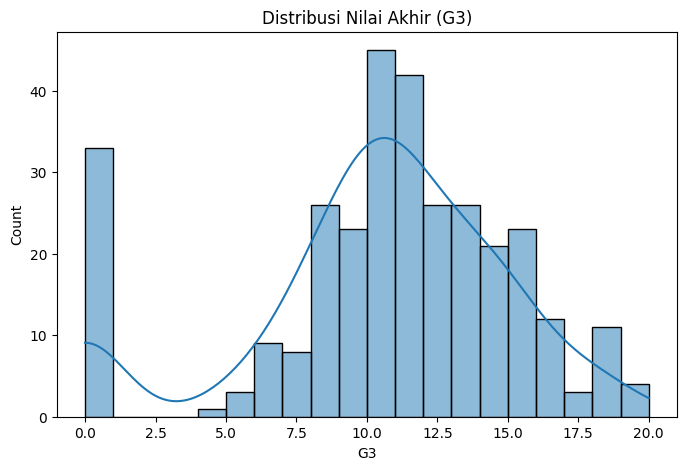

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(train_df['G3'], bins=20, kde=True)
plt.title('Distribusi Nilai Akhir (G3)')
plt.show()

# 5. Data Preprocessing

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.
Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.
Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
TARGET_COL = 'Label Kelulusan (0/1)'

if 'G3' in train_df.columns:
    train_df[TARGET_COL] = train_df['G3'].apply(lambda x: 1 if x >= 10 else 0)
    test_df[TARGET_COL] = test_df['G3'].apply(lambda x: 1 if x >= 10 else 0)

cols_to_drop = ['G1', 'G2', 'G3']
train_df = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
test_df = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])

In [8]:
cat_cols = train_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = test_df[col].apply(lambda x: x if x in le.classes_ else train_df[col].mode()[0])
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    test_df[col] = test_df[col].map(le_dict).fillna(train_df[col].mode()[0]).astype(int)

In [9]:
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != TARGET_COL]

scaler = StandardScaler()
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

In [10]:
train_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,Label Kelulusan (0/1)
0,-0.347228,1.079066,-0.586396,0.528538,-0.631055,0.335673,0.246437,0.423207,0.697239,-0.266113,...,0.438694,1.378072,0.064432,-1.195981,-0.144396,-0.55443,-0.266496,-0.368473,-0.464408,1
1,-0.347228,1.079066,-0.586396,0.528538,-0.631055,0.335673,-0.680636,0.423207,-0.109822,-0.266113,...,0.438694,-0.725651,1.195575,-0.214345,-0.144396,-0.55443,-1.039089,-0.368473,-0.702257,1
2,-0.347228,-0.926727,-0.586396,0.528538,-0.631055,0.335673,-1.607709,0.423207,-1.723943,0.885829,...,0.438694,1.378072,0.064432,-0.214345,1.644982,-0.55443,-1.039089,-0.368473,-0.702257,0
3,-0.347228,-0.926727,-0.586396,0.528538,-0.631055,0.335673,1.173510,0.423207,1.504299,-1.418056,...,0.438694,-0.725651,-1.066710,0.767292,0.750293,0.55443,1.278690,0.341512,-0.464408,0
4,-0.347228,1.079066,-0.586396,-1.892012,-0.631055,0.335673,-0.680636,-1.434203,-0.109822,-0.266113,...,-2.279491,-0.725651,-1.066710,-0.214345,-1.039085,-0.55443,0.506097,-0.368473,-0.702257,0


In [11]:
os.makedirs('../student_preprocessing', exist_ok=True)
train_df.to_csv('../student_preprocessing/train.csv', index=False)
test_df.to_csv('../student_preprocessing/test.csv', index=False)
print('Data bersih berhasil disimpan ke ../student_preprocessing')

Data bersih berhasil disimpan ke ../student_preprocessing
